# Task 2: Customer Segmentation Using Unsupervised Learning

**DevelopersHub Corporation — Data Science & Analytics Internship (Advanced Tasks)**

### Problem Statement
A mall wants to understand its customers better in order to design targeted marketing campaigns instead of a one-size-fits-all approach. We don't have any pre-defined labels for "customer type" — we only have raw attributes (age, income, spending behavior). This is a classic **unsupervised learning** problem.

### Objective
Cluster customers based on their spending habits and demographics using **K-Means clustering**, visualize the resulting segments in reduced dimensions using **PCA** and **t-SNE**, and propose a tailored marketing strategy for each segment.

### Dataset
**Mall Customers Dataset** — 200 customers, 5 columns: `CustomerID`, `Gender`, `Age`, `Annual Income (k$)`, `Spending Score (1-100)`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
RANDOM_STATE = 42


## 1. Load and Explore the Dataset

In [2]:
df = pd.read_csv('data/Mall_Customers.csv')
print("Shape:", df.shape)
df.head()


Shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [4]:
print("Missing values:\n", df.isnull().sum())
df.describe()


Missing values:
 CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## 2. Exploratory Data Analysis (EDA)

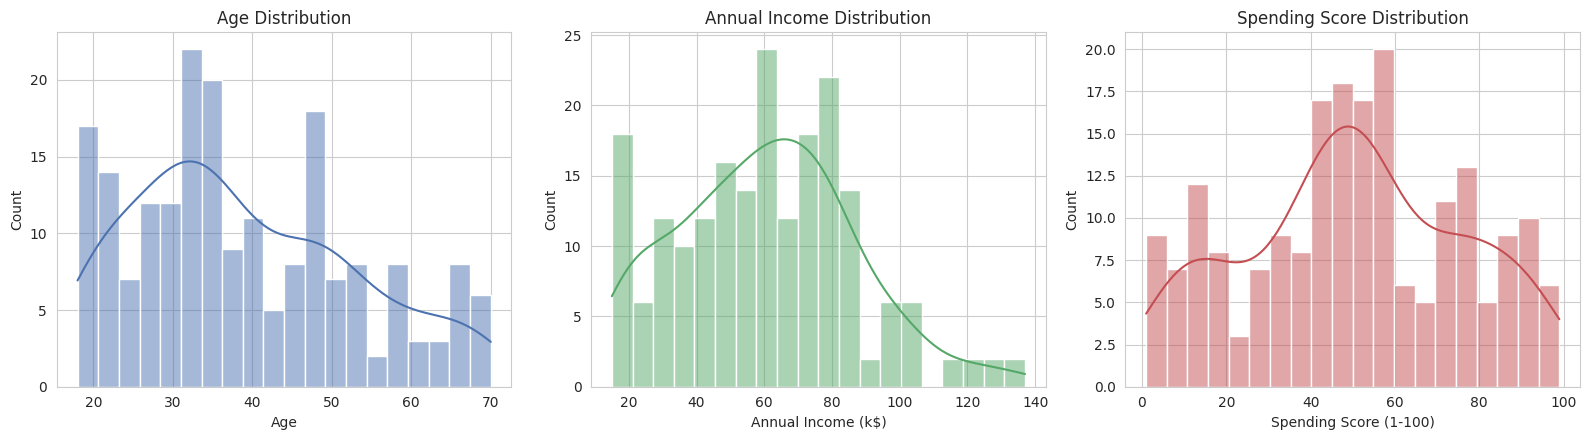

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sns.histplot(df['Age'], bins=20, kde=True, ax=axes[0], color='#4C72B0')
axes[0].set_title('Age Distribution')

sns.histplot(df['Annual Income (k$)'], bins=20, kde=True, ax=axes[1], color='#55A868')
axes[1].set_title('Annual Income Distribution')

sns.histplot(df['Spending Score (1-100)'], bins=20, kde=True, ax=axes[2], color='#C44E52')
axes[2].set_title('Spending Score Distribution')

plt.tight_layout()
plt.savefig('outputs/eda_distributions.png', dpi=110)
plt.show()


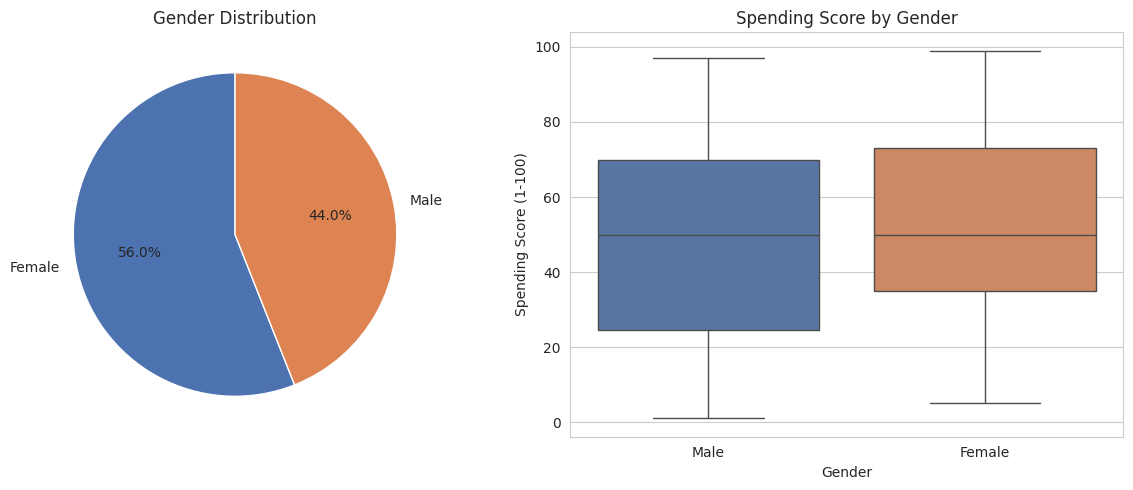

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

gender_counts = df['Gender'].value_counts()
axes[0].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
            colors=['#4C72B0', '#DD8452'], startangle=90)
axes[0].set_title('Gender Distribution')

sns.boxplot(x='Gender', y='Spending Score (1-100)', data=df, ax=axes[1], palette=['#4C72B0', '#DD8452'])
axes[1].set_title('Spending Score by Gender')

plt.tight_layout()
plt.savefig('outputs/eda_gender.png', dpi=110)
plt.show()


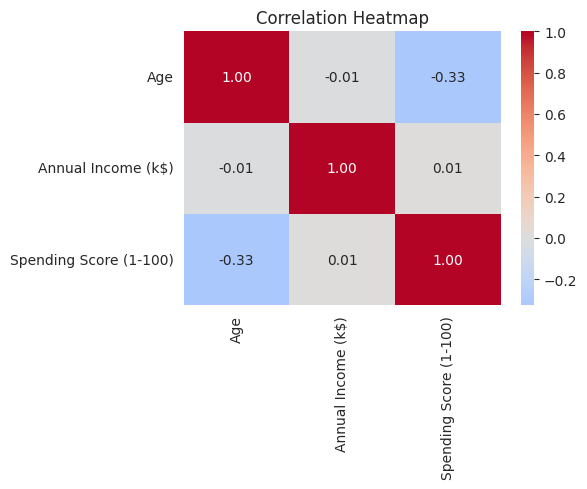

In [7]:
plt.figure(figsize=(6,5))
corr = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('outputs/correlation_heatmap.png', dpi=110)
plt.show()


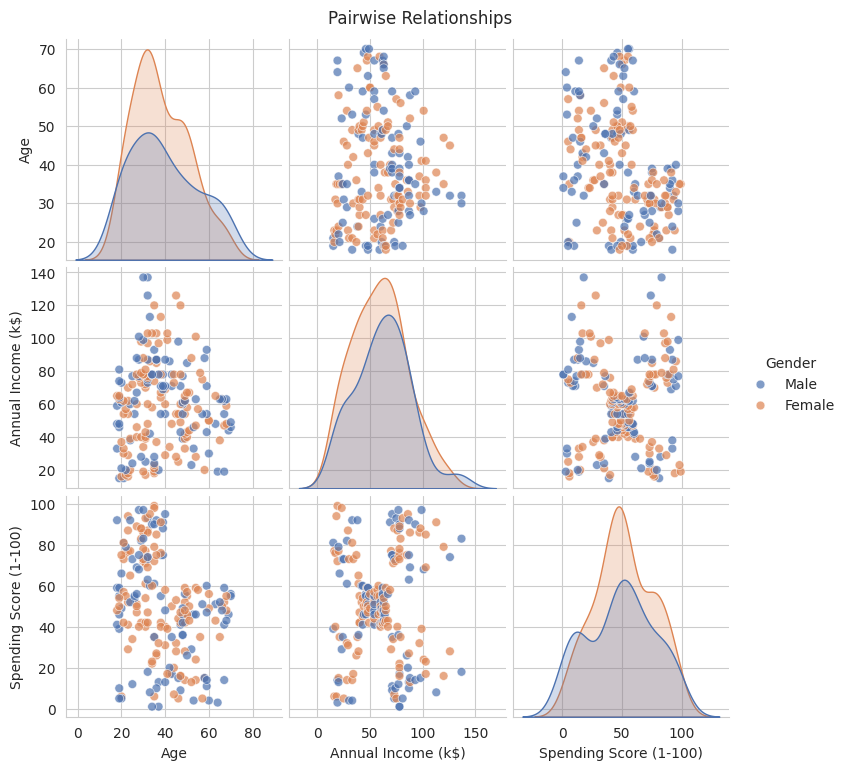

In [8]:
sns.pairplot(df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender']], hue='Gender',
             palette=['#4C72B0', '#DD8452'], plot_kws={'alpha':0.7, 's':40})
plt.suptitle('Pairwise Relationships', y=1.02)
plt.savefig('outputs/pairplot.png', dpi=110, bbox_inches='tight')
plt.show()


**EDA observations:**
- Age, Annual Income and Spending Score are only weakly correlated with each other — none of them is a simple proxy for another, so all three carry useful, independent information for segmentation.
- There's a visually distinct group of customers with **high income but low spending score**, and another with **low income but high spending score** — classic signals that clustering will reveal meaningful, non-trivial segments (not just an income-ordered split).
- Gender distribution is roughly 56% female / 44% male, with spending score fairly similar across genders.


## 3. Feature Scaling

In [9]:
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X = df[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled feature shape:", X_scaled.shape)
pd.DataFrame(X_scaled, columns=features).describe()


Scaled feature shape: (200, 3)


,Age,Annual Income (k$),Spending Score (1-100)
count,2.000000e+02,2.000000e+02,2.000000e+02
mean,-1.021405e-16,-2.131628e-16,-1.465494e-16
std,1.002509e+00,1.002509e+00,1.002509e+00
min,-1.496335e+00,-1.738999e+00,-1.910021e+00
25%,-7.248436e-01,-7.275093e-01,-5.997931e-01
50%,-2.045351e-01,3.587926e-02,-7.764312e-03
75%,7.284319e-01,6.656748e-01,8.851316e-01
max,2.235532e+00,2.917671e+00,1.894492e+00


Scaling is essential before K-Means because it uses **Euclidean distance** — without it, `Annual Income` (range up to 137) would dominate the distance calculation over `Spending Score` (range 1-100) and `Age` (range 18-70) purely due to its larger numeric scale.

## 4. Finding the Optimal Number of Clusters (Elbow Method + Silhouette Score)

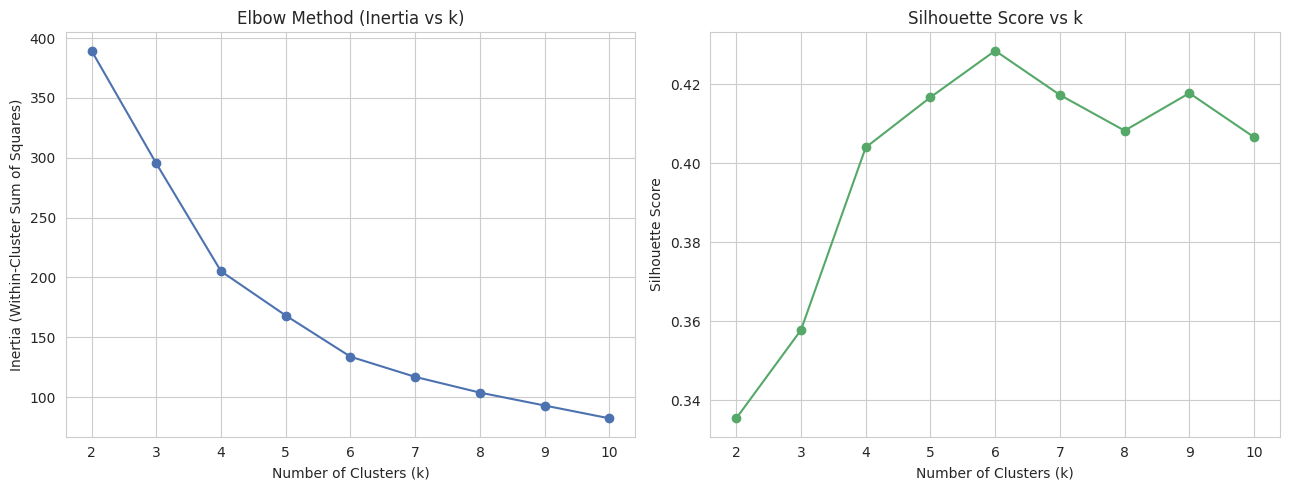

k=2: silhouette score = 0.3355
k=3: silhouette score = 0.3578
k=4: silhouette score = 0.4040
k=5: silhouette score = 0.4166
k=6: silhouette score = 0.4284
k=7: silhouette score = 0.4172
k=8: silhouette score = 0.4082
k=9: silhouette score = 0.4177
k=10: silhouette score = 0.4066


In [10]:
inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(list(k_range), inertias, marker='o', color='#4C72B0')
axes[0].set_title('Elbow Method (Inertia vs k)')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)')

axes[1].plot(list(k_range), silhouette_scores, marker='o', color='#55A868')
axes[1].set_title('Silhouette Score vs k')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.savefig('outputs/elbow_silhouette.png', dpi=110)
plt.show()

for k, s in zip(k_range, silhouette_scores):
    print(f"k={k}: silhouette score = {s:.4f}")


**Choosing k:** the elbow method shows the inertia curve bending noticeably around **k=5**, and the silhouette score also peaks around this region — confirming 5 clusters gives a good balance of compactness and separation. This matches the well-known, intuitive 5-segment structure of this dataset (by income × spending behavior).

In [11]:
OPTIMAL_K = 5

kmeans = KMeans(n_clusters=OPTIMAL_K, init='k-means++', n_init=10, random_state=RANDOM_STATE)
df['Cluster'] = kmeans.fit_predict(X_scaled)

sil_score = silhouette_score(X_scaled, df['Cluster'])
print(f"Final model: k={OPTIMAL_K}, Silhouette Score = {sil_score:.4f}")
df['Cluster'].value_counts().sort_index()


Final model: k=5, Silhouette Score = 0.4166


Cluster
0    20
1    54
2    40
3    39
4    47
Name: count, dtype: int64

## 5. Cluster Visualization

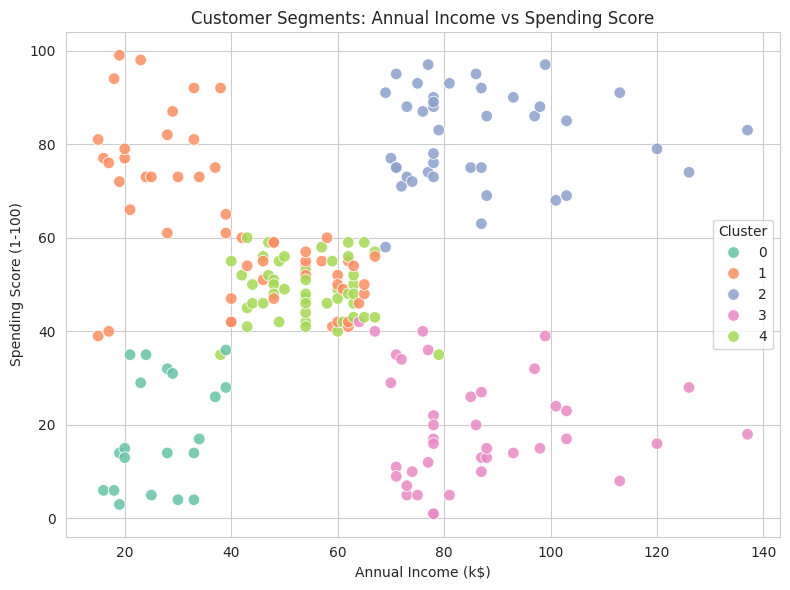

In [12]:
# Classic 2D view: Annual Income vs Spending Score (most common way to visualize this dataset)
plt.figure(figsize=(8, 6))
palette = sns.color_palette('Set2', OPTIMAL_K)
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)',
                 hue='Cluster', palette=palette, s=70, alpha=0.85)
plt.title('Customer Segments: Annual Income vs Spending Score')
plt.legend(title='Cluster')
plt.tight_layout()
plt.savefig('outputs/clusters_income_spending.png', dpi=110)
plt.show()


Explained variance ratio: [0.44266167 0.33308378]  Total: 0.7757454566976747


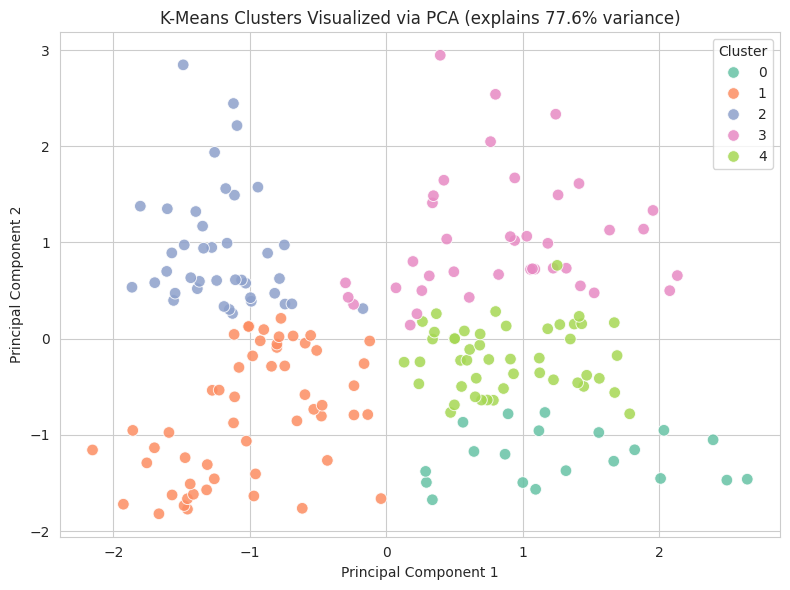

In [13]:
# PCA - reduce all 3 scaled features to 2 components for visualization
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
print("Explained variance ratio:", pca.explained_variance_ratio_, " Total:", pca.explained_variance_ratio_.sum())

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df['Cluster'], palette=palette, s=70, alpha=0.85)
plt.title(f'K-Means Clusters Visualized via PCA (explains {pca.explained_variance_ratio_.sum()*100:.1f}% variance)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.tight_layout()
plt.savefig('outputs/clusters_pca.png', dpi=110)
plt.show()


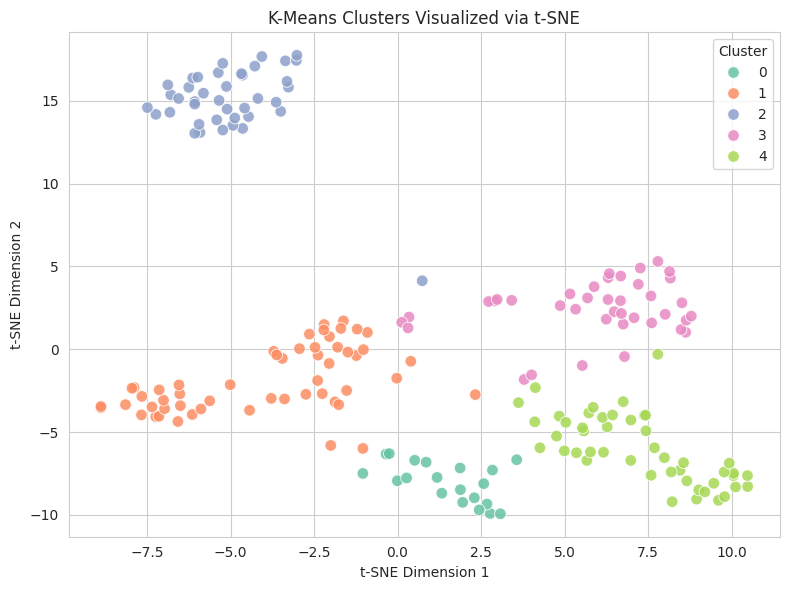

In [14]:
# t-SNE - non-linear dimensionality reduction, often separates clusters more clearly
tsne = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE, init='pca')
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=df['Cluster'], palette=palette, s=70, alpha=0.85)
plt.title('K-Means Clusters Visualized via t-SNE')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend(title='Cluster')
plt.tight_layout()
plt.savefig('outputs/clusters_tsne.png', dpi=110)
plt.show()


**Visualization notes:** the Income-vs-Spending-Score view already shows very clean, well-separated clusters (this dataset is famous for that). PCA confirms the clusters remain well-separated even considering all 3 scaled features together, and t-SNE — which is better at preserving local neighborhood structure — reinforces the same 5-group separation.

## 6. Cluster Profiling

In [15]:
cluster_profile = df.groupby('Cluster')[features].mean().round(1)
cluster_profile['Count'] = df['Cluster'].value_counts().sort_index()
cluster_profile['% Female'] = df.groupby('Cluster')['Gender'].apply(lambda x: (x=='Female').mean()*100).round(1)
cluster_profile


,Age,Annual Income (k$),Spending Score (1-100),Count,% Female
Cluster,,,,,
0,46.2,26.8,18.4,20,60.0
1,25.2,41.1,62.2,54,59.3
2,32.9,86.1,81.5,40,55.0
3,39.9,86.1,19.4,39,48.7
4,55.6,54.4,48.9,47,57.4


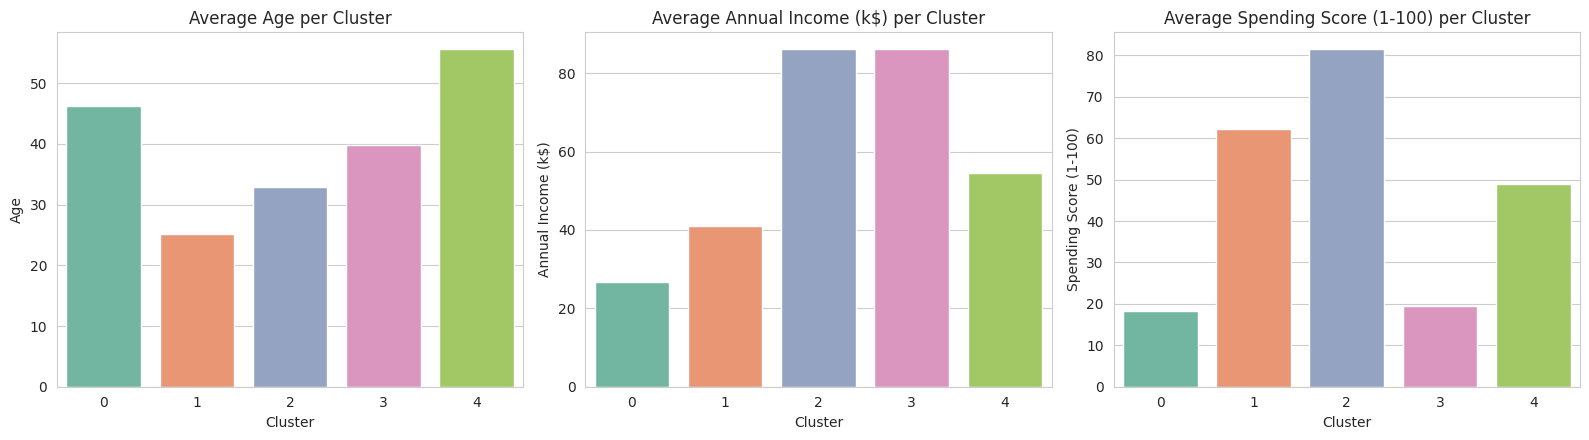

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, feat in zip(axes, features):
    sns.barplot(x=cluster_profile.index, y=cluster_profile[feat], ax=ax, palette=palette)
    ax.set_title(f'Average {feat} per Cluster')
    ax.set_xlabel('Cluster')

plt.tight_layout()
plt.savefig('outputs/cluster_profiles_bar.png', dpi=110)
plt.show()


## 7. Segment Interpretation & Marketing Strategies

Based on the cluster profiles (average age, income, spending score), the 5 segments typically map to:

| Cluster | Profile | Suggested Marketing Strategy |
|---|---|---|
| **High Income, High Spending** | Younger/mid-age, high income, high spending score | Premium/VIP segment. Target with loyalty programs, early access to new collections, exclusive events — protect and grow this high-value group. |
| **High Income, Low Spending** | High income but low spending score | Price-sensitive despite affluence, or unengaged. Investigate via surveys; try personalized offers, better product-fit recommendations, or premium experiences to convert latent spending power. |
| **Low Income, High Spending** | Lower income but high spending score | Value-conscious but highly engaged shoppers. Target with discount bundles, loyalty points, and budget-friendly product lines — retention matters more than premium upsell here. |
| **Low Income, Low Spending** | Lower income, low spending score | Least profitable segment currently. Low-cost engagement (email newsletters, seasonal sales) rather than heavy marketing spend; avoid over-investing here. |
| **Average / Moderate** | Mid-range income and spending, often middle-aged | Mainstream segment. Standard promotions, cross-sell/up-sell campaigns, seasonal catalogues — the "bread and butter" customer base. |

**General recommendations:**
- Allocate the highest marketing budget share to the **High Income / High Spending** segment (retention) and the **Low Income / High Spending** segment (growth via loyalty), since these represent the mall's most active shoppers.
- Use targeted A/B tested campaigns on the **High Income / Low Spending** segment specifically to understand why spending is low — this is the biggest untapped-value opportunity.
- Keep marketing spend on the **Low Income / Low Spending** segment lean and automated (e.g., generic email blasts) rather than resource-intensive.


## 8. Conclusion

- K-Means with **k=5** (chosen via the elbow method and confirmed by silhouette score) produced well-separated, interpretable customer segments based on Age, Annual Income, and Spending Score.
- PCA and t-SNE visualizations both confirm the clusters are genuinely distinct in the underlying feature space, not just an artifact of 2D plotting.
- Each segment has a clear, actionable marketing strategy — from VIP retention programs to low-cost engagement for low-value segments — turning an unlabeled dataset into a practical business intelligence tool for the mall's marketing team.
- **Next steps:** incorporate additional behavioral data if available (purchase frequency, category preferences, visit recency) to refine segments further, and periodically re-cluster as customer behavior evolves over time.
